### Brightness Correlation Experiment

We define the safe manifold as the distribution of embeddings computed from daytime corridor images, representing nominal operating conditions for the robot. This reflects a realistic deployment constraint in which the system is intended to operate under well-lit conditions, while low-light environments (e.g., nighttime) may introduce safety risks due to reduced visibility.

To evaluate whether brightness correlates with deviation from this manifold, we simulate out-of-distribution (OOD) inputs by systematically reducing image brightness. For each modified image, we compute its embedding and measure the distance to the safe centroid (the mean embedding of the training set).

In [1]:
!pip install torch torchvision matplotlib scikit-learn tqdm pillow ftfy regex git+https://github.com/openai/CLIP.git -q

In [2]:
import sys
sys.path.append('../')
from config import PLT_STYLE

In [3]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pathlib import Path

plt.rcParams.update(PLT_STYLE)

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print(f"Device: {device}")

Device: cpu


In [6]:
def get_embedding(image):
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        return model.encode_image(image_tensor).cpu().numpy().flatten()

def darken_image(img, factor):
    return ImageEnhance.Brightness(img).enhance(factor)

#### 1. Load Corridor Images

In [7]:
corridor_dir = Path("data/images/corridor")
image_paths = list(corridor_dir.glob("*.jpg")) + list(corridor_dir.glob("*.jpeg")) + list(corridor_dir.glob("*.png"))
print(f"Found {len(image_paths)} images")

Found 346 images


In [8]:
loaded_images = []
for img_path in image_paths:
    try:
        loaded_images.append(Image.open(img_path).convert('RGB'))
    except:
        pass
print(f"Loaded {len(loaded_images)} images")

Loaded 346 images


In [9]:
train_imgs, test_imgs = train_test_split(loaded_images, test_size=0.2, random_state=42)
print(f"Train: {len(train_imgs)}, Test: {len(test_imgs)}")

Train: 276, Test: 70


#### 2. Compute Safe Centroid

In [10]:
train_embs = np.array([get_embedding(img) for img in tqdm(train_imgs)])
centroid = np.mean(train_embs, axis=0)
print("Centroid computed")

100%|██████████| 276/276 [00:10<00:00, 25.53it/s]

Centroid computed


#### 3. Measure Distance Across Brightness Levels

In [11]:
brightness_levels = np.linspace(1.0, 0.1, 10)
results = []

for factor in tqdm(brightness_levels):
    dists = [np.linalg.norm(get_embedding(darken_image(img, factor)) - centroid) for img in test_imgs]
    results.append(np.mean(dists))
    print(f"Brightness {factor:.2f}: distance = {results[-1]:.4f}")

 10%|█         | 1/10 [00:02<00:24,  2.68s/it]

Brightness 1.00: distance = 5.7948


 20%|██        | 2/10 [00:05<00:21,  2.75s/it]

Brightness 0.90: distance = 5.8021


 30%|███       | 3/10 [00:08<00:19,  2.77s/it]

...

Brightness 0.30: distance = 6.5427


 90%|█████████ | 9/10 [00:24<00:02,  2.78s/it]

Brightness 0.20: distance = 6.9648


100%|██████████| 10/10 [00:27<00:00,  2.77s/it]

Brightness 0.10: distance = 7.6612


#### 4. Visualize Correlation

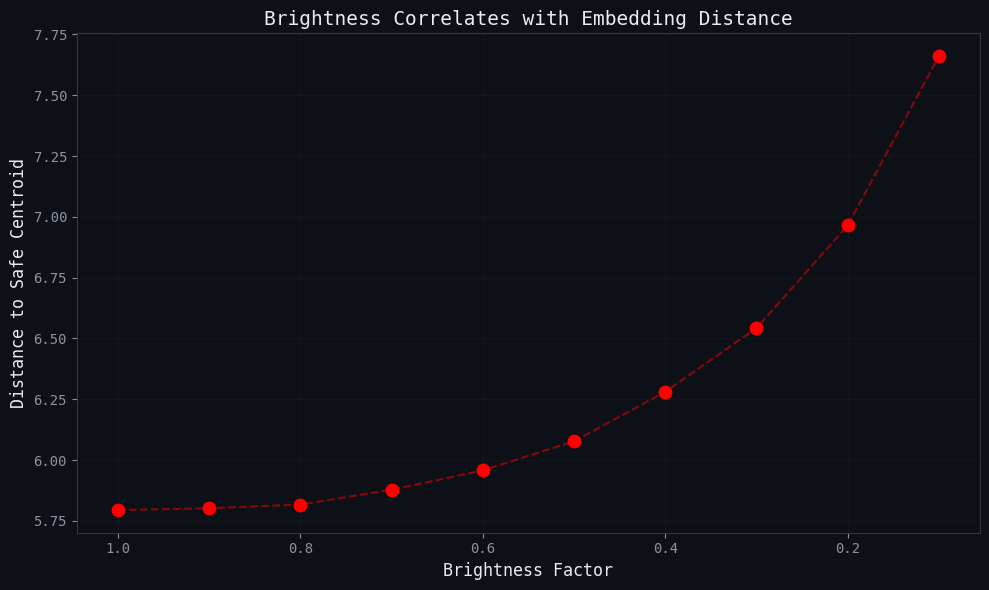

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(brightness_levels, results, c='red', s=80, zorder=3)
plt.plot(brightness_levels, results, 'r--', alpha=0.5, zorder=2)
plt.xlabel('Brightness Factor', fontsize=12)
plt.ylabel('Distance to Safe Centroid', fontsize=12)
plt.title('Brightness Correlates with Embedding Distance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig('brightness_correlation.png', dpi=150)
plt.show()

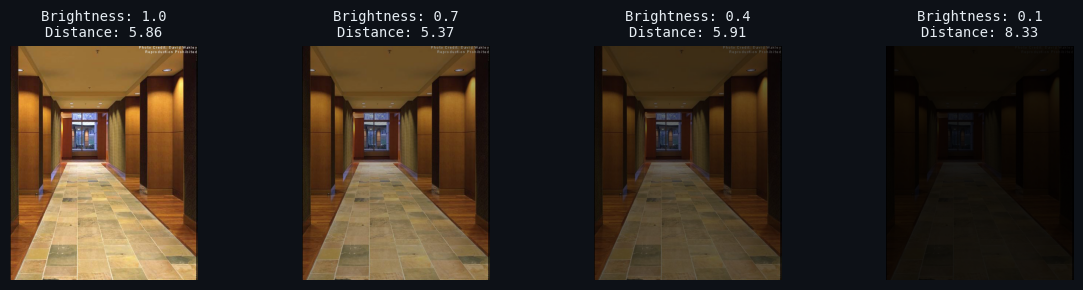

In [ ]:
sample_img = test_imgs[42]

display_levels = [1.0, 0.7, 0.4, 0.1]
fig, axes = plt.subplots(1, len(display_levels), figsize=(12, 3))

for idx, factor in enumerate(display_levels):
    darkened = darken_image(sample_img, factor)
    emb = get_embedding(darkened)
    dist = np.linalg.norm(emb - centroid)
    
    axes[idx].imshow(darkened)
    axes[idx].set_title(f'Brightness: {factor:.1f}\nDistance: {dist:.2f}', fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('brightness_distance_examples.png', dpi=150)
plt.show()

#### Summary

Our results confirms that for our use case where the safe manifold is defined using daytime corridor images, brightness serves as a valid proxy for OOD detection.